# Flight Delay Classification with Logistic Regression + SMOTE

This notebook shows how to train and evaluate a logistic‐regression classifier on a (heavily) imbalanced flight‐delay dataset by:

1. Loading and inspecting the cleaned data  
2. Defining numeric & categorical features  
3. Building a `ColumnTransformer` for preprocessing  
4. Wrapping it all in an imbalanced‐learn `Pipeline` (preprocess → SMOTE → logistic‐regression)  
5. Splitting stratified train/test, fitting, predicting  
6. Reporting classification metrics and plotting a confusion matrix  


In [2]:
# Cell 2: Imports & Settings
%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection   import train_test_split
from sklearn.compose           import ColumnTransformer
from sklearn.preprocessing     import OneHotEncoder, StandardScaler
from imblearn.pipeline         import Pipeline as ImbPipeline
from imblearn.over_sampling    import SMOTE
from sklearn.linear_model      import LogisticRegression
from sklearn.metrics           import classification_report, confusion_matrix

sns.set_style("whitegrid")


In [3]:
# Cell 3: Load the cleaned dataset
data_path = "/Users/pbat/Projects/cmor438/data/Cleaned_dataset.csv"
df = pd.read_csv(data_path)
df.head()


,Date_of_journey,Journey_day,Airline,Flight_code,Class,Source,Departure,Total_stops,Arrival,Destination,Duration_in_hours,Days_left,Fare
0,1/16/2023,Monday,SpiceJet,SG-8169,Economy,Delhi,After 6 PM,non-stop,After 6 PM,Mumbai,2.0833,1,5335
1,1/16/2023,Monday,Indigo,6E-2519,Economy,Delhi,After 6 PM,non-stop,Before 6 AM,Mumbai,2.3333,1,5899
2,1/16/2023,Monday,GO FIRST,G8-354,Economy,Delhi,After 6 PM,non-stop,Before 6 AM,Mumbai,2.1667,1,5801
3,1/16/2023,Monday,SpiceJet,SG-8709,Economy,Delhi,After 6 PM,non-stop,After 6 PM,Mumbai,2.0833,1,5794
4,1/16/2023,Monday,Air India,AI-805,Economy,Delhi,After 6 PM,non-stop,After 6 PM,Mumbai,2.1667,1,5955


In [3]:
# Cell 4: Examine class distribution
print(df['Class'].value_counts())


Class
Economy            252033
Business           126834
Premium Economy     73077
First                 144
Name: count, dtype: int64


In [4]:
# Cell 5: Define X and y
X = df.drop(columns=["Flight_code", "Class"])
y = df["Class"]


In [5]:
# Cell 6: Columns
numeric_cols     = ["Duration_in_hours", "Days_left", "Fare"]
categorical_cols = [
    "Journey_day", "Airline", "Source",
    "Departure", "Total_stops", "Arrival", "Destination"
]

preprocessor = ColumnTransformer([
    ("num", StandardScaler(),                numeric_cols),
    ("cat", OneHotEncoder(drop="first",      sparse_output=False), categorical_cols)
])


##  Imbalanced‐learn pipeline  
1) Preprocess  
2) SMOTE up‐sampling  
3) Multinomial logistic regression (saga solver, balanced weights)


In [6]:
# Cell 7: Build the full pipeline
clf = ImbPipeline([
    ("pre",   preprocessor),
    ("smote", SMOTE(random_state=42)),
    ("lr",    LogisticRegression(
                  multi_class="multinomial",
                  solver="saga",
                  class_weight="balanced",
                  max_iter=1000,
                  verbose=1
             ))
])


In [7]:
# Cell 8: Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train shape:", X_train.shape, "Test shape:", X_test.shape)


Train shape: (361670, 11) Test shape: (90418, 11)


In [9]:
# Cell 9: Fit the pipeline and predict
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)


/Users/pbat/Library/Python/3.13/lib/python/site-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Epoch 1, change: 1
Epoch 2, change: 0.040263031
Epoch 3, change: 0.016828727
Epoch 4, change: 0.01364472
Epoch 5, change: 0.013531482
Epoch 6, change: 0.013073227
Epoch 7, change: 0.011844469
Epoch 8, change: 0.011037859
Epoch 9, change: 0.0097258123
Epoch 10, change: 0.0092402496
Epoch 11, change: 0.0085724017
Epoch 12, change: 0.0081345333
Epoch 13, change: 0.0070419198
Epoch 14, change: 0.0067869538
Epoch 15, change: 0.0060673162
Epoch 16, change: 0.0058427314
Epoch 17, change: 0.0052703052
Epoch 18, change: 0.004762376
Epoch 19, change: 0.0045461705
Epoch 20, change: 0.0043026728
Epoch 21, change: 0.0040924947
Epoch 22, change: 0.0037658827
Epoch 23, change: 0.0036240755
Epoch 24, change: 0.0034528152
Epoch 25, change: 0.0032919384
Epoch 26, change: 0.0031415599
Epoch 27, change: 0.0029946578
Epoch 28, change: 0.0028071217
Epoch 29, change: 0.0026471927
Epoch 30, change: 0.0025295044
Epoch 31, change: 0.0024003747
Epoch 32, change: 0.0022804495
Epoch 33, change: 0.0021774996
Epoch 

[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:  1.2min finished


                 precision    recall  f1-score   support

       Business       0.99      0.98      0.99     25367
        Economy       0.98      0.78      0.87     50407
          First       0.91      1.00      0.95        29
Premium Economy       0.55      0.93      0.69     14615

       accuracy                           0.86     90418
      macro avg       0.86      0.92      0.87     90418
   weighted avg       0.91      0.86      0.87     90418



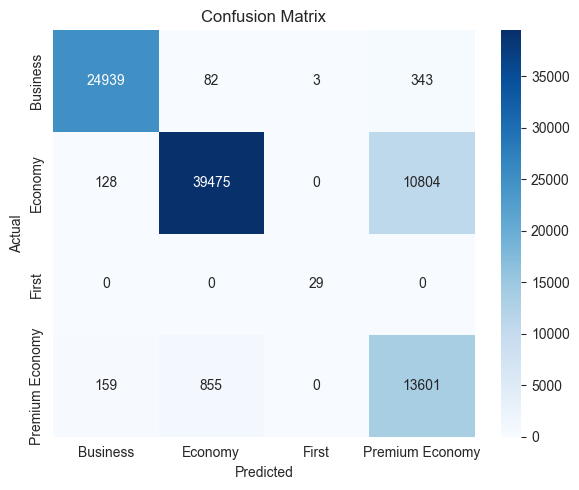

In [10]:
# Cell 10: Metrics
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred, labels=clf.classes_)
plt.figure(figsize=(6,5))
sns.heatmap(
    cm, annot=True, fmt="d",
    xticklabels=clf.classes_, yticklabels=clf.classes_,
    cmap="Blues"
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()


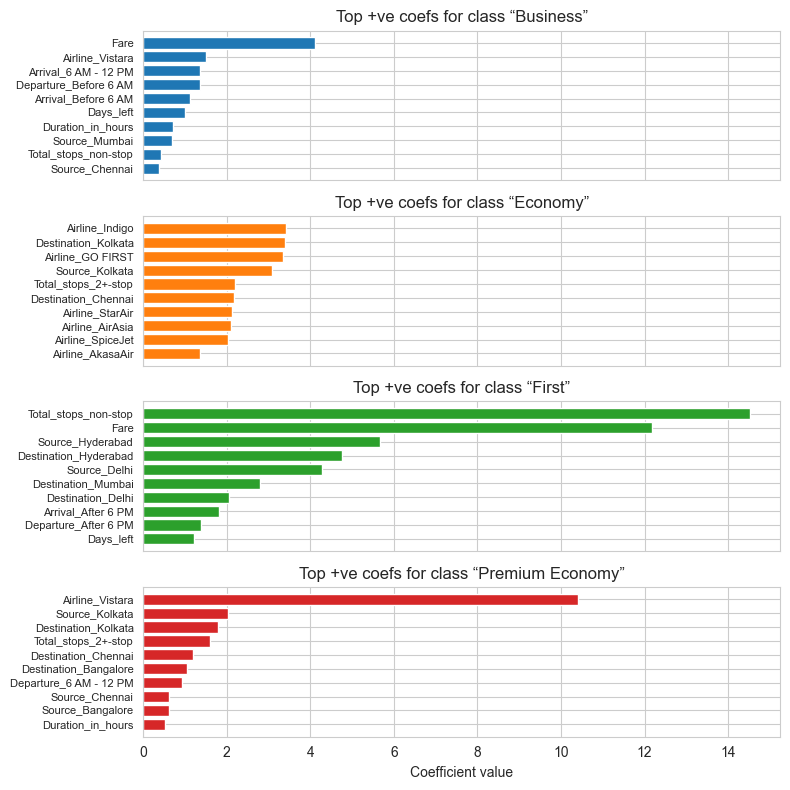

In [13]:
import numpy as np

# get feature names after preprocessing
num_feats = numeric_cols
cat_feats = clf.named_steps["pre"] \
                .named_transformers_["cat"] \
                .get_feature_names_out(categorical_cols)
all_feats = np.concatenate([num_feats, cat_feats])

coefs = clf.named_steps["lr"].coef_  # shape (n_classes, n_features)

fig, ax = plt.subplots(len(classes), 1, figsize=(8, 2*len(classes)), sharex=True)
for i, cls in enumerate(classes):
    coef = coefs[i]
    idx  = np.argsort(coef)
    ax[i].barh(np.array(all_feats)[idx][-10:], coef[idx][-10:], color="C{}".format(i))
    ax[i].set_title(f"Top +ve coefs for class “{cls}”")
    ax[i].tick_params(axis="y", labelsize=8)
plt.xlabel("Coefficient value")
plt.tight_layout()
plt.show()
